## Choropleth maps

A choropleth map colours geographic regions (polygons) according to a data
value.  earthkit-plots supports choropleth maps from any GeoDataFrame —
here we use ERA5 2-metre temperature averaged over NUTS regions.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

nuts_mean_2t = ekd.from_source("sample", "era5-nuts-mean-2t.geojson").to_pandas()

In [2]:
nuts_mean_2t

,id,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,2t,geometry
0,DK,DK,0,DK,Danmark,Danmark,0,0,0,DK,278.709224,"MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996..."
1,RS,RS,0,RS,Serbia,Srbija/Сpбија,0,0,0,RS,257.467299,"POLYGON ((21.4792 45.193, 21.3585 44.8216, 22...."
2,EE,EE,0,EE,Eesti,Eesti,0,0,0,EE,275.762907,"MULTIPOLYGON (((27.357 58.7871, 27.6449 57.981..."
3,EL,EL,0,EL,Elláda,Ελλάδα,0,0,0,EL,274.514026,"MULTIPOLYGON (((28.0777 36.1182, 27.8606 35.92..."
4,ES,ES,0,ES,España,España,0,0,0,ES,273.998565,"MULTIPOLYGON (((4.391 39.8617, 4.1907 39.7981,..."
5,FI,FI,0,FI,Suomi/Finland,Suomi/Finland,0,0,0,FI,273.595243,"MULTIPOLYGON (((28.8967 69.0426, 28.4782 68.51..."
6,FR,FR,0,FR,France,France,0,0,0,FR,270.832357,"MULTIPOLYGON (((55.8498 -21.1858, 55.7858 -21...."
7,HR,HR,0,HR,Hrvatska,Hrvatska,0,0,0,HR,262.673420,"MULTIPOLYGON (((17.6515 45.8478, 17.9121 45.79..."
8,HU,HU,0,HU,Magyarország,Magyarország,0,0,0,HU,264.999617,"POLYGON ((22.1211 48.3783, 22.1553 48.4034, 22..."
9,IE,IE,0,IE,Éire/Ireland,Éire/Ireland,0,0,0,IE,282.472782,"POLYGON ((-7.1885 54.3377, -6.8642 54.3302, -6..."


### Plotting the raw GeoDataFrame

You can pass a GeoDataFrame directly to `ekp.geo.choropleth`.  When no
value column is specified, earthkit-plots uses a categorical colour scheme
so you can immediately see the shape and coverage of the regions.

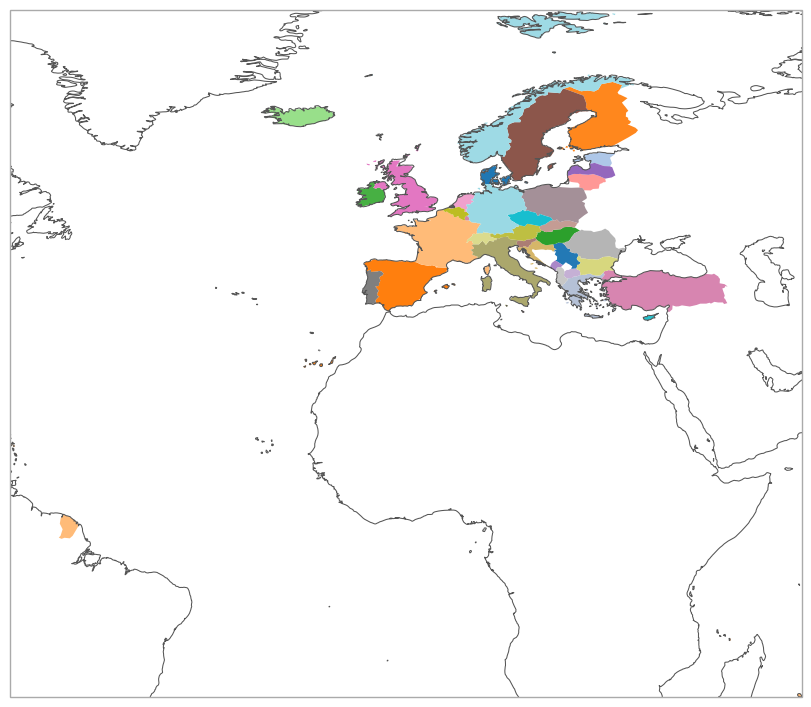

In [3]:
ekp.geo.choropleth(nuts_mean_2t)

### Colouring by a data column

Pass the `z` argument to select the column whose values drive the colour
scale.  Here we colour each NUTS region by its mean 2-metre temperature.

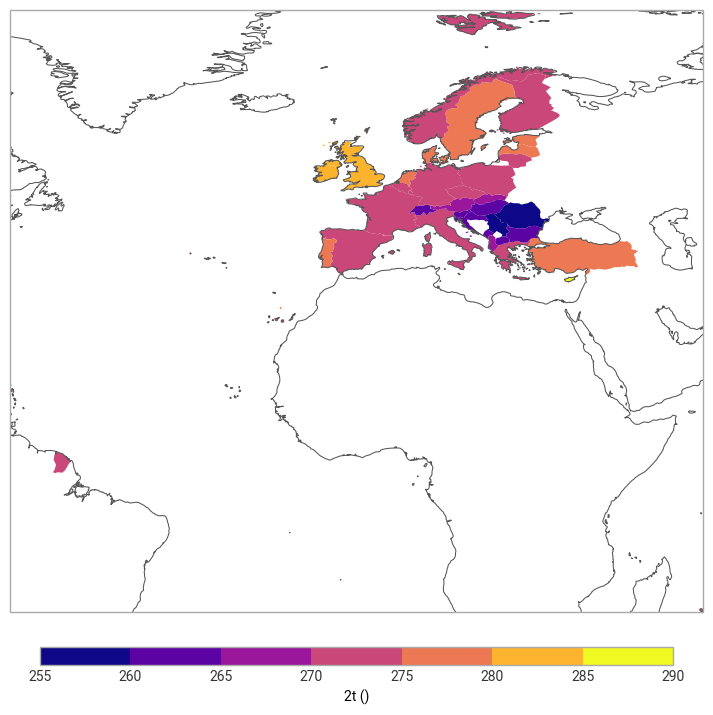

In [4]:
ekp.geo.choropleth(nuts_mean_2t, z="2t")

### Adding a domain and data labels

`ekp.geo.choropleth` accepts the same `domain` argument as other
earthkit-plots functions.  You can also overlay text labels on each region
using a format string that references column names in curly braces.

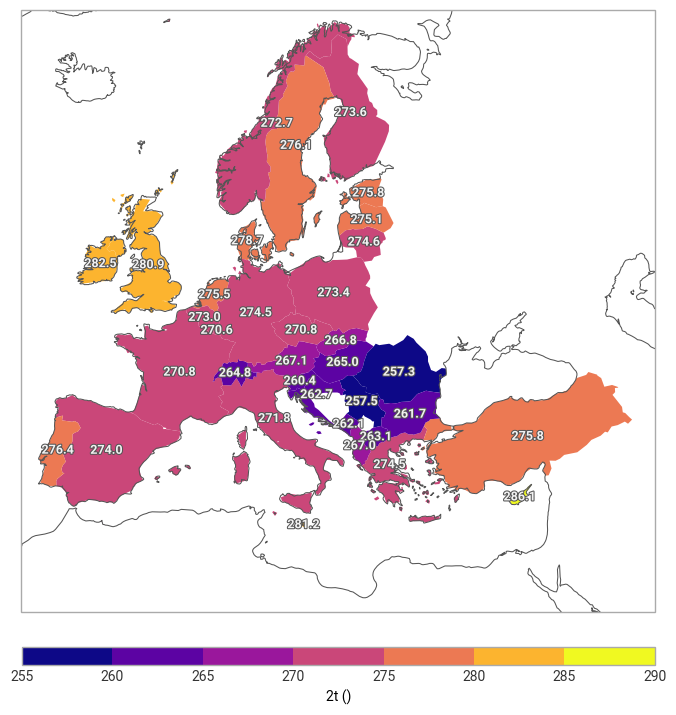

In [5]:
ekp.geo.choropleth(nuts_mean_2t, z="2t", domain="Europe", labels="{2t:.1f}")

### Reusable styles and metadata

As with other plot types you can pass a `Style` object to control colour
levels and the colour map, and a `metadata` dict to provide unit and
long-name information for unit conversion plus title and label formatting.

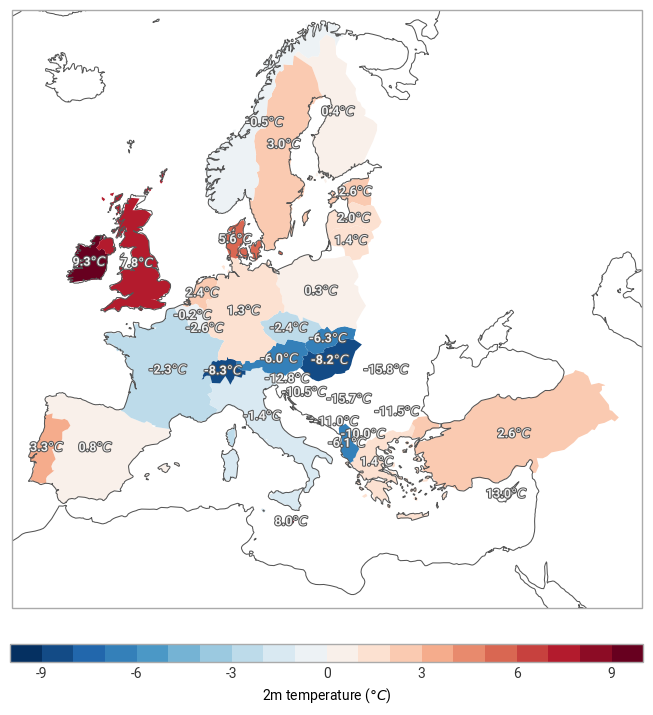

In [6]:
style = ekp.styles.Style(
    levels=range(-10, 11),
    cmap="RdBu_r",
    units="celsius",
)

ekp.geo.choropleth(
    nuts_mean_2t,
    domain="Europe",
    z="2t",
    labels="{2t:.1f}{units}",
    metadata={"units": "K", "long_name": "2m temperature"},
    style=style,
).show()